# Temporal Analysis

This notebook reproduces the three key temporal figures / tables reported in the paper:

| Output | Description |
|--------|-------------|
| **Figure 1** | Quarterly Rule Creation Volume and Predicate-Changing Revision Volume (line charts) |
| **Table 2** | Summary statistics: Prevalence · Frequency · Timing · Edit magnitude (LaTeX) |
| **Figure 2** | Stacking plot: cohort-consistent structural-change accumulation by post-creation lag |

## Data sources

| File | Role |
|------|------|
| `build_data/rule_versions_{repo}.jsonl` | Version-level commit dates for the date lookup. |
| `build_data/lineage_metadata_final_{repo}.json` | Per-lineage creation date, active/deleted flag. |
| `align_data/all_steps_{repo}.jsonl` | One row per adjacent version pair: `d_step`, `is_noop`, etc. |

**Key definitions**

- *Predicate-changing revision* — an adjacent version pair where `d_step > 0`.
- *Creation quarter* — the quarter containing `first_commit_date` of the lineage.
- *Edit quarter* — the quarter of `commit_date` for `version_b` in a step row.
- *Lag* — integer difference in quarters between creation_q and edit_q.

In [1]:
# ── Imports and configuration ─────────────────────────────────────────────
import json
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', 80)

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# ── Paths ─────────────────────────────────────────────────────────────────
REPO_ROOT  = Path('../..').resolve()
BUILD_DATA = REPO_ROOT / 'data_prep' / 'build_data'
ALIGN_DATA = REPO_ROOT / 'data_prep' / 'align_data'

FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# ── Dataset labels ────────────────────────────────────────────────────────
DATASETS = {
    'Sigma':     'sigma',
    'SSC': 'ssc',
}

CORPUS_COLORS = {
    'Sigma':     '#00d6ff',
    'SSC': '#f68c25',
}

# ── Snapshot date (right-censoring endpoint for active lineages) ──────────
SNAPSHOT_DATE = datetime(2026, 4, 10, tzinfo=timezone.utc)

print(f'REPO_ROOT   : {REPO_ROOT}')
print(f'BUILD_DATA  : {BUILD_DATA}')
print(f'ALIGN_DATA  : {ALIGN_DATA}')
print(f'SNAPSHOT    : {SNAPSHOT_DATE.date()}')

REPO_ROOT   : /Users/elena/Desktop/Evolution-of-Log-Based-Detection-Rules
BUILD_DATA  : /Users/elena/Desktop/Evolution-of-Log-Based-Detection-Rules/data_prep/build_data
ALIGN_DATA  : /Users/elena/Desktop/Evolution-of-Log-Based-Detection-Rules/data_prep/align_data
SNAPSHOT    : 2026-04-10


## Helper functions and data loading

- `parse_utc(s)` — parse ISO-8601 strings to UTC-aware datetimes.
- `quarter_label(dt)` — return `'YYYY-QN'` for a datetime.
- `quarter_to_date(q)` — convert `'YYYY-QN'` to the first day of that quarter.
- `build_repo_dataframes(repo, label)` — load and join version dates, lineage metadata, and step rows into tidy DataFrames.

Returns three DataFrames:
- `df_steps` — one row per adjacent version pair (enriched with dates).
- `df_rules_all` — one row per lineage observed in `rule_versions_{repo}.jsonl`.
- `df_rules` — step-eligible lineages only (at least one adjacent version pair, so `d_step`-based timing is defined).

In [2]:
# ── Utility helpers ───────────────────────────────────────────────────────
def savefig(name):
    """Save current figure as PDF in FIGURES_DIR."""
    plt.savefig(FIGURES_DIR / f'{name}.pdf', dpi=150, bbox_inches='tight')
    print(f'  Saved: figures/{name}.pdf')
    
def parse_utc(s):
    """Parse an ISO-8601 timestamp string to a UTC-aware datetime.
    Returns None when input is None, empty, or malformed.
    """
    if not s:
        return None
    s = str(s).strip()
    if s.endswith('Z'):
        s = s[:-1] + '+00:00'
    try:
        dt = datetime.fromisoformat(s)
    except ValueError:
        return None
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(timezone.utc)


def quarter_label(dt):
    """Return 'YYYY-QN' for a datetime, or None if dt is None / NaT."""
    if dt is None:
        return None
    try:
        if pd.isnull(dt):
            return None
    except (TypeError, ValueError):
        pass
    return f'{dt.year}-Q{(dt.month - 1) // 3 + 1}'


def quarter_to_date(q_str):
    """Convert 'YYYY-QN' to the first calendar day of that quarter."""
    year, q = q_str.split('-Q')
    month = (int(q) - 1) * 3 + 1
    return datetime(int(year), month, 1)


def safe_days(dt_from, dt_to):
    """Return integer days between two datetimes; None if either is missing."""
    try:
        if dt_from is None or dt_to is None:
            return None
        if pd.isnull(dt_from) or pd.isnull(dt_to):
            return None
        return int((dt_to - dt_from).days)
    except Exception:
        return None


# ── Per-repo data loader ───────────────────────────────────────────────────

def build_repo_dataframes(repo, label):
    """Load and join all data for one repository.

    Parameters
    ----------
    repo  : str   e.g. 'ssc' or 'sigma'
    label : str   display name, e.g. 'SplunkSC'

    Returns
    -------
    df_steps      : DataFrame  — one row per adjacent version pair
    df_rules_all  : DataFrame  — one row per lineage in rule_versions
    df_rules      : DataFrame  — step-eligible lineages only
    """
    # 1. Version date lookup: (lineage_id, version_index) -> datetime
    rv_path = BUILD_DATA / f'rule_versions_{repo}.jsonl'
    version_dates = {}
    rv_lineage_ids = set()
    lineage_creation_dates = {}
    with rv_path.open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            lid = rec['lineage_id']
            rv_lineage_ids.add(lid)
            commit_dt = parse_utc(rec.get('commit_date'))
            version_dates[(lid, rec['version_index'])] = commit_dt
            if commit_dt is not None:
                prev = lineage_creation_dates.get(lid)
                if prev is None or commit_dt < prev:
                    lineage_creation_dates[lid] = commit_dt

    # 2. Lineage metadata: lineage_id -> {first_commit_date, ...}
    meta_path = BUILD_DATA / f'lineage_metadata_final_{repo}.json'
    with meta_path.open(encoding='utf-8') as f:
        meta_dict = {m['lineage_id']: m for m in json.load(f)}

    # 3. Load step rows and enrich with dates
    step_path = ALIGN_DATA / f'all_steps_{repo}.jsonl'
    step_rows = []
    with step_path.open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            step = json.loads(line)
            lid       = step['lineage_id']
            edit_dt   = version_dates.get((lid, step['version_b']))
            creation_dt = lineage_creation_dates.get(
                lid,
                parse_utc(meta_dict.get(lid, {}).get('first_commit_date')),
            )
            edit_yq   = quarter_label(edit_dt)
            step_rows.append({
                'corpus':              label,
                'lineage_id':          lid,
                'version_a':           step['version_a'],
                'version_b':           step['version_b'],
                'd_step':              float(step['d_step']),
                'is_noop':             bool(step.get('is_noop', False)),
                'creation_dt':         creation_dt,
                'edit_dt':             edit_dt,
                'days_since_creation': safe_days(creation_dt, edit_dt),
                'edit_year_quarter':   edit_yq,
            })

    df_steps = pd.DataFrame(step_rows)

    # 4. Per-lineage rule-level aggregation
    events = df_steps[df_steps['d_step'] > 0]
    edit_agg = (
        events.groupby('lineage_id').agg(
            n_positive_distance_events=('d_step', 'count'),
            first_edit_dt=('edit_dt', 'min'),
            last_edit_dt=('edit_dt', 'max'),
        ).reset_index()
    )

    lineage_ids = sorted(rv_lineage_ids)
    base_rows = []
    for lid in lineage_ids:
        meta = meta_dict.get(lid, {})
        cdt  = lineage_creation_dates.get(lid, parse_utc(meta.get('first_commit_date')))
        base_rows.append({
            'corpus':                label,
            'lineage_id':            lid,
            'creation_dt':           cdt,
            'creation_year_quarter': quarter_label(cdt),
        })

    df_rules_all = (
        pd.DataFrame(base_rows)
        .merge(edit_agg, on='lineage_id', how='left')
    )
    df_rules_all['n_positive_distance_events'] = (
        df_rules_all['n_positive_distance_events'].fillna(0).astype(int)
    )
    df_rules_all['days_to_first_edit'] = df_rules_all.apply(
        lambda r: safe_days(r['creation_dt'], r.get('first_edit_dt')), axis=1
    )
    df_rules_all['lifetime_days'] = df_rules_all.apply(
        lambda r: safe_days(r['creation_dt'], r.get('last_edit_dt')), axis=1
    )

    eligible_lineage_ids = sorted(df_steps['lineage_id'].dropna().unique())
    df_rules = df_rules_all[df_rules_all['lineage_id'].isin(eligible_lineage_ids)].copy()

    return df_steps, df_rules_all, df_rules


# ── Build combined dataframes ──────────────────────────────────────────────
print('Loading data...')
all_steps_parts = []
all_rules_all_parts = []
all_rules_parts = []

for label, repo in DATASETS.items():
    print(f'  {label} ({repo})...')
    df_s, df_r_all, df_r = build_repo_dataframes(repo, label)
    all_steps_parts.append(df_s)
    all_rules_all_parts.append(df_r_all)
    all_rules_parts.append(df_r)

df_steps = pd.concat(all_steps_parts, ignore_index=True)
df_rules_all = pd.concat(all_rules_all_parts, ignore_index=True)
df_rules = pd.concat(all_rules_parts, ignore_index=True)

# Convenience subsets
events_df = df_steps[df_steps['d_step'] > 0].copy()
active_df  = df_rules[df_rules['n_positive_distance_events'] > 0].copy()

print(f'\ndf_steps  : {len(df_steps):,} rows  '
      f'({len(events_df):,} with d_step > 0)')
print(f'df_rules_all : {len(df_rules_all):,} rows  '
      f'(all lineages in rule_versions)')
print(f'df_rules     : {len(df_rules):,} rows  '
      f'(step-eligible lineages with >= 2 versions)')
for label in DATASETS:
    r_all = df_rules_all[df_rules_all['corpus'] == label]
    r = df_rules[df_rules['corpus'] == label]
    a = active_df[active_df['corpus'] == label]
    e = events_df[events_df['corpus'] == label]
    print(f'  {label}: {len(r_all):,} total versioned rules; '
          f'{len(r):,} step-eligible; {len(a):,} edited ({100*len(a)/len(r):.1f}%), '
          f'{len(e):,} predicate-changing events')

Loading data...
  Sigma (sigma)...
  SSC (ssc)...

df_steps  : 146,566 rows  (12,902 with d_step > 0)
df_rules_all : 6,859 rows  (all lineages in rule_versions)
df_rules     : 6,519 rows  (step-eligible lineages with >= 2 versions)
  Sigma: 4,204 total versioned rules; 3,942 step-eligible; 2,355 edited (59.7%), 8,234 predicate-changing events
  SSC: 2,655 total versioned rules; 2,577 step-eligible; 1,493 edited (57.9%), 4,668 predicate-changing events


## Figure 2 — Quarterly Rule Creation and Predicate-Changing Revision Volume

**Rule universe used here.** All lineages observed in `rule_versions_{repo}.jsonl` are counted for creation volume, including single-commit rules with no adjacent revision pair.

Two panels:
- **Top**: number of new lineages created per calendar quarter.
- **Bottom**: number of predicate-changing revision events (`d_step > 0`) per quarter.

Both time series use the same x-axis (calendar time).

In [3]:
def next_quarter_start(period):
    """First calendar day of the quarter immediately following *period* ('YYYY-QN')."""
    yr, q = period.split('-Q')
    yr, q = int(yr), int(q)
    if q == 4:
        return datetime(yr + 1, 1, 1)
    return datetime(yr, q * 3 + 1, 1)


# ── Aggregate: creation volume ─────────────────────────────────────────────
creation_q = {}
for label in DATASETS:
    sub = df_rules[
        (df_rules_all['corpus'] == label) &
        df_rules_all['creation_year_quarter'].notna()
    ]
    creation_q[label] = (
        sub.groupby('creation_year_quarter')
        .size()
        .reset_index(name='n_rules')
        .rename(columns={'creation_year_quarter': 'period'})
    )

# ── Aggregate: revision volume ─────────────────────────────────────────────
revision_q = {}
for label in DATASETS:
    sub = events_df[
        (events_df['corpus'] == label) &
        events_df['edit_year_quarter'].notna()
    ]
    revision_q[label] = (
        sub.groupby('edit_year_quarter')
        .size()
        .reset_index(name='n_events')
        .rename(columns={'edit_year_quarter': 'period'})
    )

# ── Quarter geometry helpers ────────────────────────────────────────────────
all_periods = sorted(
    set().union(*[d['period'].tolist() for d in creation_q.values()],
               *[d['period'].tolist() for d in revision_q.values()])
)

def q_mid(p):
    """Datetime at the exact centre of quarter *p*."""
    start = quarter_to_date(p)
    end   = next_quarter_start(p)
    return start + timedelta(days=(end - start).days / 2)

def q_bar_width(p, gap=0.12):
    """Bar width in days = actual quarter duration * (1 - gap)."""
    start = quarter_to_date(p)
    end   = next_quarter_start(p)
    return (end - start).days * (1 - gap)




/var/folders/j4/1g43plmj3xl1lgh8rsjt7r8r0000gn/T/ipykernel_24725/3728016128.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sub = df_rules[
/var/folders/j4/1g43plmj3xl1lgh8rsjt7r8r0000gn/T/ipykernel_24725/3728016128.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sub = df_rules[


  Saved: figures/fig_temporal_quarterly_lines_vertical.pdf


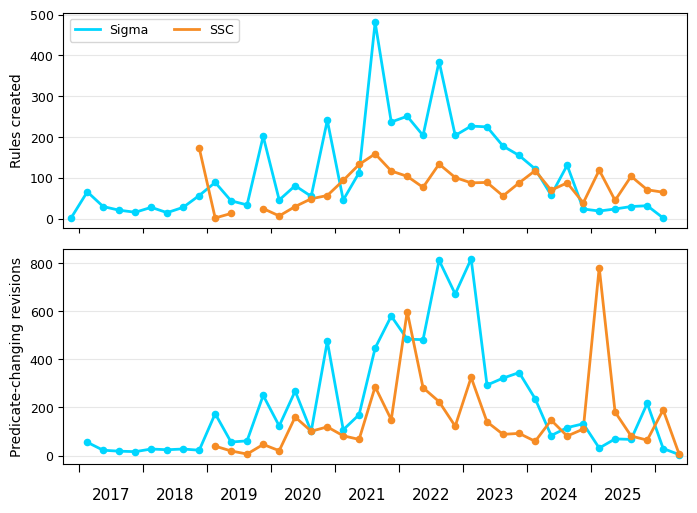

In [4]:
def quarter_range(start_period, end_period):
    """Inclusive list of quarter labels from start_period to end_period."""
    periods = []
    current = start_period
    while True:
        periods.append(current)
        if current == end_period:
            return periods
        year, quarter = current.split('-Q')
        year, quarter = int(year), int(quarter)
        if quarter == 4:
            current = f'{year + 1}-Q1'
        else:
            current = f'{year}-Q{quarter + 1}'


def live_complete_quarter_series(source_dict, label, value_col, end_period):
    """Zero-fill only after the repository becomes live; omit pre-live quarters."""
    live_periods = sorted(
        set(creation_q[label]['period']).union(revision_q[label]['period'])
    )
    live_start = live_periods[0]
    periods = quarter_range(live_start, end_period)
    return (
        pd.DataFrame({'period': periods})
        .merge(source_dict[label][['period', value_col]], on='period', how='left')
        .fillna({value_col: 0})
    )


def draw_partial_year_labels(ax, periods, y=-0.085):
    """Label only complete four-quarter years; keep partial years unlabeled."""
    if not periods:
        return
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mticker.NullFormatter())
    ax.tick_params(axis='x', which='major', length=6, direction='out', width=0.8, pad=6)

    xform = ax.get_xaxis_transform()
    years_in_data = sorted(set(int(p.split('-Q')[0]) for p in periods))
    for year in years_in_data:
        year_periods = [p for p in periods if p.startswith(f'{year}-')]
        if len(year_periods) != 4:
            continue
        start = quarter_to_date(year_periods[0])
        end = next_quarter_start(year_periods[-1])
        mid = start + timedelta(days=(end - start).days / 2)
        ax.text(
            mdates.date2num(mid), y,
            str(year),
            transform=xform,
            ha='center', va='top',
            fontsize=11,
        )

shared_periods = sorted(
    set().union(*[df['period'].tolist() for df in creation_q.values()],
               *[df['period'].tolist() for df in revision_q.values()])
)
shared_start = shared_periods[0]
shared_end = shared_periods[-1]
displayed_periods = quarter_range(shared_start, shared_end)

fig, axes = plt.subplots(2, 1, figsize=(7.1, 5.4), sharex=True, sharey=False)
panel_specs = [
    (creation_q, 'n_rules', 'Rules created'),
    (revision_q, 'n_events', 'Predicate-changing revisions'),
]

for ax, (source_dict, value_col, ylabel) in zip(axes, panel_specs):
    for label in DATASETS:
        sub = live_complete_quarter_series(source_dict, label, value_col, shared_end)
        mid_dates = [q_mid(p) for p in sub['period']]
        positive_mask = sub[value_col] > 0
        line_values = sub[value_col].where(positive_mask, np.nan)

        ax.plot(
            mid_dates, line_values,
            color=CORPUS_COLORS[label], linewidth=2.0,
            label=label,
        )
        ax.scatter(
            [d for d, keep in zip(mid_dates, positive_mask) if keep],
            sub.loc[positive_mask, value_col],
            color=CORPUS_COLORS[label], s=20, zorder=3,
        )

    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlim(quarter_to_date(shared_start), next_quarter_start(shared_end))
    ax.margins(x=0)

axes[0].legend(loc='upper left', ncol=2, frameon=True, fontsize=9)
axes[0].tick_params(axis='x', which='both', labelbottom=False)
draw_partial_year_labels(axes[1], displayed_periods, y=-0.11)

plt.tight_layout(rect=[0, 0.03, 1, 1])
savefig('fig_temporal_quarterly_lines_vertical')
plt.show()
plt.close()

In [ ]:
# ── Reference table ────────────────────────────────────────────────────────
# One row per quarter: creation count and edit-event count for each corpus.
labels_ord = list(DATASETS.keys())
table_parts = []
for label in labels_ord:
    created = creation_q[label].rename(columns={'n_rules': f'{label} created'})
    revised = revision_q[label].rename(columns={'n_events': f'{label} edits'})
    part = created.merge(revised, on='period', how='outer').sort_values('period')
    if table_parts:
        table_parts[0] = table_parts[0].merge(part, on='period', how='outer')
    else:
        table_parts.append(part)

ref_table = table_parts[0].sort_values('period').reset_index(drop=True)
ref_table = ref_table.fillna(0).astype(
    {col: int for col in ref_table.columns if col != 'period'}
)
print('Reference table (creation and edit counts per quarter):')
display(ref_table)


Reference table (creation and edit counts per quarter):


,period,Sigma created,Sigma edits,SSC created,SSC edits
0,2016-Q4,3,0,0,0
1,2017-Q1,66,55,0,0
2,2017-Q2,30,22,0,0
3,2017-Q3,21,18,0,0
4,2017-Q4,16,16,0,0
5,2018-Q1,28,27,0,0
6,2018-Q2,15,24,0,0
7,2018-Q3,28,27,0,0
8,2018-Q4,57,22,173,0
9,2019-Q1,89,174,2,39


: 

## Table 2 — Temporal Summary Statistics

**Rule universe used from this section onward.** We restrict to step-eligible lineages only: rules with at least two versions (equivalently, at least one adjacent version pair in `all_steps_{repo}.jsonl`). Single-commit lineages are excluded because `d_step`-based timing and revision statistics are undefined for them.

Lifecycle statistics of predicate-changing revision steps, emitted as a paper-ready LaTeX table.

| Section | Quantities |
|---------|------------|
| **Prevalence** | Share of adjacent revision steps with `d_step > 0`; share of rules with ≥1 predicate change |
| **Frequency** | Edits per edited rule (median, mean, P90) |
| **Timing** | Days to first predicate-changing revision (median, %≤90d, %>730d) |
| **Edit magnitude** | `d_step` distribution over predicate-changing steps (median, mean, P25, P90, max) |

In [7]:
# ── Per-corpus summary statistics ────────────────────────────────────────

def corpus_stats(label):
    """Compute all summary statistics for one corpus."""
    all_rules   = df_rules[df_rules['corpus'] == label]
    all_steps   = df_steps[df_steps['corpus'] == label]
    edited      = active_df[active_df['corpus'] == label]
    evts        = events_df[events_df['corpus'] == label]

    n_rules     = len(all_rules)
    n_steps     = len(all_steps)
    n_edited    = len(edited)
    pct_steps_changed = 100.0 * len(evts) / n_steps if n_steps else float('nan')
    pct_edited  = 100.0 * n_edited / n_rules if n_rules else float('nan')
    n_events    = len(evts)

    edit_counts = edited['n_positive_distance_events']
    first_days  = edited['days_to_first_edit'].dropna()
    dstep       = evts['d_step']

    return {
        # Prevalence
        'n_rules':              n_rules,
        'n_steps':              n_steps,
        'n_edited':             n_edited,
        'pct_steps_changed':    pct_steps_changed,
        'pct_edited':           pct_edited,
        'n_events':             n_events,
        # Frequency
        'freq_median':          edit_counts.median() if len(edit_counts) else float('nan'),
        'freq_mean':            edit_counts.mean()   if len(edit_counts) else float('nan'),
        'freq_p90':             edit_counts.quantile(0.90) if len(edit_counts) else float('nan'),
        # Timing
        'timing_median':        first_days.median()           if len(first_days) else float('nan'),
        'timing_pct_le90':      100.0 * (first_days <= 90).mean()  if len(first_days) else float('nan'),
        'timing_pct_gt730':     100.0 * (first_days > 730).mean()  if len(first_days) else float('nan'),
        # Edit magnitude
        'mag_median':           dstep.median()           if len(dstep) else float('nan'),
        'mag_mean':             dstep.mean()             if len(dstep) else float('nan'),
        'mag_p25':              dstep.quantile(0.25)     if len(dstep) else float('nan'),
        'mag_p90':              dstep.quantile(0.90)     if len(dstep) else float('nan'),
        'mag_max':              dstep.max()              if len(dstep) else float('nan'),
    }


stats = {label: corpus_stats(label) for label in DATASETS}

# ── Console preview ───────────────────────────────────────────────────────
for label, s in stats.items():
    print(f'\n{label}')
    for k, v in s.items():
        print(f'  {k:<28}: {v:.2f}' if isinstance(v, float) else f'  {k:<28}: {v}')


# ── LaTeX table ──────────────────────────────────────────────────────────
def fmt_pct(x):    return f'{x:.1f}\\%'
def fmt_f1(x):     return f'{x:.1f}'
def fmt_f2(x):     return f'{x:.2f}'
def fmt_int(x):    return f'{int(x):,}'

labels = ['SSC', 'Sigma']

def row(desc, vals):
    return f'  {desc} & ' + ' & '.join(vals) + r' \\'

def section(title):
    return f"  \\multicolumn{{1}}{{c}}{{\\textit{{{title}}}}} & & \\\\" 


Sigma
  n_rules                     : 3942
  n_steps                     : 39480
  n_edited                    : 2355
  pct_steps_changed           : 20.86
  pct_edited                  : 59.74
  n_events                    : 8234
  freq_median                 : 2.00
  freq_mean                   : 3.50
  freq_p90                    : 7.00
  timing_median               : 60.00
  timing_pct_le90             : 54.39
  timing_pct_gt730            : 8.03
  mag_median                  : 2.00
  mag_mean                    : 5.31
  mag_p25                     : 0.80
  mag_p90                     : 13.00
  mag_max                     : 359.00

SSC
  n_rules                     : 2577
  n_steps                     : 107086
  n_edited                    : 1493
  pct_steps_changed           : 4.36
  pct_edited                  : 57.94
  n_events                    : 4668
  freq_median                 : 2.00
  freq_mean                   : 3.13
  freq_p90                    : 7.00
  timing_median

## Figure 3 — Cohort-Consistent Structural Change Accumulation

**Rule universe used here.** This section continues to use the step-eligible subset introduced for Table 2, so cohort sizes exclude single-commit lineages with no adjacent revision pair.

**What it shows.** Each bar stack corresponds to one *creation cohort* (a calendar quarter in which rules were created). The stacked segments represent contributions from edits that occurred at different *post-creation lags* (measured in quarters since the lineage was first committed). The y-axis is normalised by cohort size:
$$\text{contribution}(C, k) = \frac{\sum_{r\in C}\,d_{\text{step}}(r,k)}{N_C}$$
so cohorts of different sizes are comparable.

**Color scheme.** Lags are grouped into post-creation *years* (4 consecutive quarters). Each year gets a distinct hue; the four quarters within a year progress from a lighter tint (first quarter) to the full hue (fourth quarter). This makes it easy to read both *which year* the edits happened and *whether early or late quarters within that year* dominate.

**X-axis.** Year labels are centered horizontally under the four quarterly bars of that calendar year; major tick marks fall between years.

In [5]:
# ── Quarter arithmetic helpers ────────────────────────────────────────────

def q_to_idx(q_str):
    """Convert 'YYYY-QN' to a monotone integer (4*year + N-1)."""
    year, q = q_str.split('-Q')
    return int(year) * 4 + int(q) - 1


def lag_quarters(creation_q, edit_q):
    """Return integer lag = q_to_idx(edit_q) - q_to_idx(creation_q), or None."""
    if not creation_q or not edit_q:
        return None
    return q_to_idx(edit_q) - q_to_idx(creation_q)


# ── Build stacking dataframe ───────────────────────────────────────────────
print('Building stacking-plot dataframe...')

stk = events_df[['corpus', 'lineage_id', 'edit_year_quarter', 'd_step',
                  'creation_dt']].copy()
stk['creation_q'] = stk['creation_dt'].apply(quarter_label)
stk['edit_q']     = stk['edit_year_quarter']
stk['lag'] = stk.apply(
    lambda r: lag_quarters(r['creation_q'], r['edit_q']), axis=1
)

# Exclusions
n_total    = len(stk)
n_null_lag = stk['lag'].isna().sum()
n_neg_lag  = (stk['lag'].notna() & (stk['lag'] < 0)).sum()
stk_valid  = stk[stk['lag'].notna() & (stk['lag'] >= 0)].copy()
stk_valid['lag'] = stk_valid['lag'].astype(int)

print(f'  Total events     : {n_total:,}')
print(f'  Missing lag      : {n_null_lag:,}')
print(f'  Negative lag     : {n_neg_lag:,}')
print(f'  Retained (lag>=0): {len(stk_valid):,}')

# ── Cohort sizes (denominator) ────────────────────────────────────────────
cohort_sizes = (
    df_rules[df_rules['creation_year_quarter'].notna()]
    .groupby(['corpus', 'creation_year_quarter'])
    .size()
    .reset_index(name='N_C')
    .rename(columns={'creation_year_quarter': 'creation_q'})
)

# ── Aggregate: sum d_step per (corpus, creation_q, lag) ──────────────────
agg = (
    stk_valid
    .groupby(['corpus', 'creation_q', 'lag'])['d_step']
    .sum()
    .reset_index(name='sum_d_step')
    .merge(cohort_sizes, on=['corpus', 'creation_q'], how='left')
)
agg = agg[agg['N_C'].fillna(0) > 0].copy()
agg['contrib'] = agg['sum_d_step'] / agg['N_C']

# ── Pivot to (cohort x lag) per corpus ────────────────────────────────────
pivoted = {}
for label in DATASETS:
    cqs  = sorted(
        df_rules[
            (df_rules['corpus'] == label) &
            df_rules['creation_year_quarter'].notna()
        ]['creation_year_quarter'].unique()
    )
    lags = sorted(agg[agg['corpus'] == label]['lag'].unique().astype(int))
    sub  = agg[agg['corpus'] == label]
    piv  = (
        sub.pivot_table(index='creation_q', columns='lag',
                        values='contrib', aggfunc='sum')
        .reindex(index=cqs, columns=lags)
        .fillna(0.0)
    )
    pivoted[label] = piv
    print(f'  {label}: pivot shape = {piv.shape}, '
          f'max bar height = {piv.sum(axis=1).max():.4f}')

print('Stacking data ready.')

Building stacking-plot dataframe...
  Total events     : 12,902
  Missing lag      : 0
  Negative lag     : 0
  Retained (lag>=0): 12,902
  Sigma: pivot shape = (37, 36), max bar height = 274.1333
  SSC: pivot shape = (29, 31), max bar height = 26.7290
Stacking data ready.


Distinct lags: 36  (lag 0–35)
  Saved: figures/fig_cohort_stacking_yearly_vertical.pdf


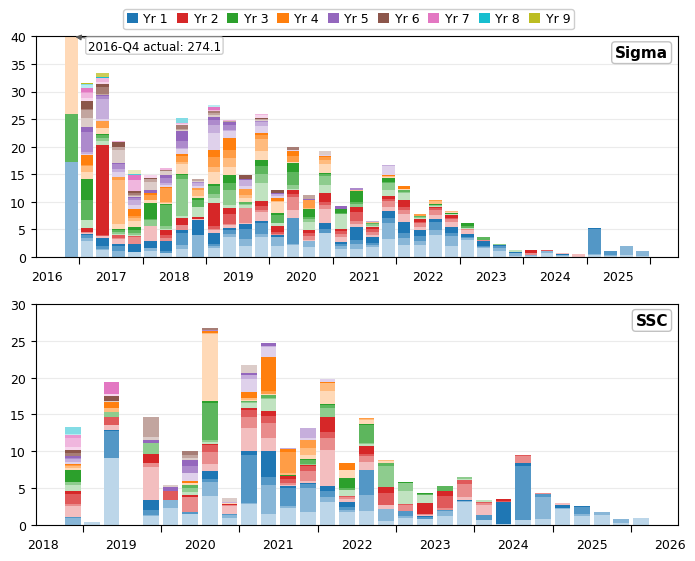

In [6]:
# ── Yearly color scheme: 4 shades per post-creation year ─────────────────
# Year 0 = lags 0-3 (creation year), Year 1 = lags 4-7, etc.
# Within each year: lag%4 == 0 is lightest, lag%4 == 3 is darkest.

YEAR_HUES = [
    '#1f77b4',  # blue       — year 0 (creation year)
    '#d62728',  # red        — year 1
    '#2ca02c',  # green      — year 2
    '#ff7f0e',  # orange     — year 3
    '#9467bd',  # purple     — year 4
    '#8c564b',  # brown      — year 5
    '#e377c2',  # pink       — year 6
    '#17becf',  # cyan       — year 7
    '#bcbd22',  # yellow-grn — year 8
    '#7f7f7f',  # gray       — year 9+
]


def lag_color(lag):
    """Color for a lag: hue from the post-creation year, shade from quarter within year."""
    year    = lag // 4
    q_in_yr = lag % 4           # 0 = lightest, 3 = full saturation
    base    = matplotlib.colors.to_rgb(YEAR_HUES[min(year, len(YEAR_HUES) - 1)])
    t = 0.30 + 0.70 * (q_in_yr / 3)   # interpolate toward white
    return tuple(c * t + (1.0 - t) for c in base)


# ── Quarter geometry (shared with the volume figure) ─────────────────────
# q_mid_stk: datetime at the exact centre of a quarter.
# Bars are centred here so they sit entirely inside the quarter,
# leaving a natural gap at every Jan-1 boundary.

def q_mid_stk(q_str):
    start = quarter_to_date(q_str)
    end   = next_quarter_start(q_str)
    return start + timedelta(days=(end - start).days / 2)

def q_bar_w(q_str, fill=0.80):
    """Bar width in days = fill fraction of the actual quarter duration."""
    start = quarter_to_date(q_str)
    end   = next_quarter_start(q_str)
    return (end - start).days * fill


# ── Collect all lags ───────────────────────────────────────────────────────
all_lags = sorted(
    set(lag for piv in pivoted.values() for lag in piv.columns.tolist())
)
print(f'Distinct lags: {len(all_lags)}  (lag {all_lags[0]}–{all_lags[-1]})')
colors = {lag: lag_color(lag) for lag in all_lags}

def draw_year_segment_labels_compact(ax, cqs, y=-0.06, fontsize=9):
    """Year labels centred under the four quarterly bars of each calendar year."""
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mticker.NullFormatter())
    ax.tick_params(axis='x', which='major', length=5, direction='out', width=0.8)

    years_in_data = sorted(set(int(q.split('-Q')[0]) for q in cqs))
    xform = ax.get_xaxis_transform()
    for yr in years_in_data:
        ax.text(
            mdates.date2num(datetime(yr, 7, 1)), y,
            str(yr),
            transform=xform,
            ha='center', va='top',
            fontsize=fontsize, rotation=0,
        )


fig, axes = plt.subplots(2, 1, figsize=(7.1, 6.0), sharex=False, sharey=False)
panel_ymax = {'Sigma': 40, 'SSC': 30}

for row_idx, label in enumerate(DATASETS):
    ax        = axes[row_idx]
    piv       = pivoted[label]
    cqs       = piv.index.tolist()
    lags_here = sorted(piv.columns.tolist())

    ymax      = panel_ymax[label]
    bar_centres = [q_mid_stk(q) for q in cqs]
    bar_widths  = [q_bar_w(q)   for q in cqs]

    bottoms = np.zeros(len(cqs), dtype=float)
    totals  = piv.sum(axis=1)
    for lag_val in lags_here:
        heights = piv[lag_val].values.astype(float)
        heights_plot = np.minimum(heights, np.maximum(ymax - bottoms, 0.0))
        ax.bar(
            bar_centres, heights_plot,
            bottom=bottoms,
            width=bar_widths,
            color=colors[lag_val],
            align='center',
            linewidth=0,
        )
        bottoms += heights_plot

    ax.set_ylim(0, ymax)
    ax.grid(True, axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=9)
    draw_year_segment_labels_compact(ax, cqs)

    ax.text(
        0.985, 0.96, label,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=11, fontweight='semibold',
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='0.75', alpha=0.95),
    )

    if label == 'Sigma' and '2016-Q4' in totals.index:
        sigma_total = float(totals.loc['2016-Q4'])
        clip_x = q_mid_stk('2016-Q4')
        ax.annotate(
            f'2016-Q4 actual: {sigma_total:.1f}',
            xy=(clip_x, ymax),
            xytext=(12, -2),
            textcoords='offset points',
            ha='left', va='top',
            fontsize=8.5,
            arrowprops=dict(arrowstyle='-|>', lw=0.8, color='0.35', shrinkA=0, shrinkB=3),
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='0.8', alpha=0.95),
        )

# Shared legend
max_yr = max(all_lags) // 4
legend_handles, legend_labels = [], []
for yr in range(max_yr + 1):
    yr_lags = [l for l in all_lags if l // 4 == yr]
    if not yr_lags:
        continue
    patch = matplotlib.patches.Patch(
        facecolor=colors[yr_lags[-1]],
        edgecolor='none',
    )
    legend_handles.append(patch)
    legend_labels.append(f'Yr {yr + 1}')

fig.legend(
    legend_handles, legend_labels,
    loc='upper center',
    ncol=len(legend_handles),
    bbox_to_anchor=(0.5, 0.96),
    fontsize=9,
    frameon=True, framealpha=0.95,
    handlelength=0.9, handleheight=0.9,
    borderpad=0.28, labelspacing=0.35, columnspacing=0.7, handletextpad=0.45,
)

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
savefig('fig_cohort_stacking_yearly_vertical')
plt.show()
plt.close()


In [9]:
# ── Figure-2 cohort drilldown: Sigma 2016-Q4 ────────────────────────────

TARGET_CORPUS = 'Sigma'
TARGET_COHORT = '2016-Q4'

sigma_meta_path = BUILD_DATA / 'lineage_metadata_final_sigma.json'
with sigma_meta_path.open(encoding='utf-8') as f:
    sigma_meta = {m['lineage_id']: m for m in json.load(f)}

cohort_n = int(
    cohort_sizes[
        (cohort_sizes['corpus'] == TARGET_CORPUS) &
        (cohort_sizes['creation_q'] == TARGET_COHORT)
    ]['N_C'].iloc[0]
)

cohort_rules = (
    df_rules[
        (df_rules['corpus'] == TARGET_CORPUS) &
        (df_rules['creation_year_quarter'] == TARGET_COHORT)
    ][['lineage_id']]
    .drop_duplicates()
    .copy()
)
cohort_rules['rule_name'] = cohort_rules['lineage_id'].map(
    lambda lid: Path(sigma_meta.get(lid, {}).get('canonical_name', lid)).name
)

lag_rule = (
    stk_valid[
        (stk_valid['corpus'] == TARGET_CORPUS) &
        (stk_valid['creation_q'] == TARGET_COHORT)
    ]
    .groupby(['lag', 'lineage_id'], as_index=False)['d_step']
    .sum()
    .merge(cohort_rules, on='lineage_id', how='left')
)
lag_rule['cohort_contrib'] = lag_rule['d_step'] / cohort_n
lag_rule = lag_rule.sort_values(['lag', 'd_step', 'lineage_id'], ascending=[True, False, True])

rule_totals = (
    lag_rule.groupby(['lineage_id', 'rule_name'], as_index=False)
    .agg(raw_d_step_total=('d_step', 'sum'),
         cohort_contrib_total=('cohort_contrib', 'sum'))
    .sort_values(['raw_d_step_total', 'lineage_id'], ascending=[False, True])
)

lag_summary = (
    lag_rule.groupby('lag', as_index=False)
    .agg(raw_d_step_total=('d_step', 'sum'),
         cohort_contrib_total=('cohort_contrib', 'sum'))
)

print(f'{TARGET_CORPUS} {TARGET_COHORT} cohort size: {cohort_n}')
print(f'Cumulated cohort edit size: {lag_summary["cohort_contrib_total"].sum():.1f}')
print('')
print('Rules in cohort:')
display(cohort_rules.sort_values(['rule_name', 'lineage_id']).reset_index(drop=True))

print('Per-rule totals across all lags:')
display(rule_totals.reset_index(drop=True))

print('Per-lag totals for the cohort:')
display(lag_summary.reset_index(drop=True))

print('Per-lag breakdown by rule:')
display(
    lag_rule[['lag', 'rule_name', 'lineage_id', 'd_step', 'cohort_contrib']]
    .reset_index(drop=True)
)


Sigma 2016-Q4 cohort size: 3
Cumulated cohort edit size: 274.1

Rules in cohort:


,lineage_id,rule_name
0,lineage_00102,win_alert_mimikatz_keywords.yml
1,lineage_01286,win_av_relevant_match.yml
2,lineage_00584,win_security_audit_log_cleared.yml


Per-rule totals across all lags:


,lineage_id,rule_name,raw_d_step_total,cohort_contrib_total
0,lineage_00102,win_alert_mimikatz_keywords.yml,519.200,173.067
1,lineage_01286,win_av_relevant_match.yml,243.800,81.267
2,lineage_00584,win_security_audit_log_cleared.yml,59.400,19.800


Per-lag totals for the cohort:


,lag,raw_d_step_total,cohort_contrib_total
0,1,51.800,17.267
1,10,26.000,8.667
2,12,58.000,19.333
3,16,10.800,3.600
4,17,0.800,0.267
5,19,80.600,26.867
6,20,252.200,84.067
7,21,221.600,73.867
8,22,21.800,7.267
9,25,79.200,26.400


Per-lag breakdown by rule:


,lag,rule_name,lineage_id,d_step,cohort_contrib
0,1,win_alert_mimikatz_keywords.yml,lineage_00102,27.800,9.267
1,1,win_security_audit_log_cleared.yml,lineage_00584,14.000,4.667
2,1,win_av_relevant_match.yml,lineage_01286,10.000,3.333
3,10,win_alert_mimikatz_keywords.yml,lineage_00102,22.000,7.333
4,10,win_security_audit_log_cleared.yml,lineage_00584,4.000,1.333
5,12,win_av_relevant_match.yml,lineage_01286,42.000,14.000
6,12,win_alert_mimikatz_keywords.yml,lineage_00102,16.000,5.333
7,16,win_security_audit_log_cleared.yml,lineage_00584,10.000,3.333
8,16,win_alert_mimikatz_keywords.yml,lineage_00102,0.800,0.267
9,17,win_av_relevant_match.yml,lineage_01286,0.800,0.267


## Case Studies — Anomalous High-Churn Rules

Two rules are chosen because they are the primary drivers of outlier cohort bars in the stacking figure:

| Rule | Corpus | Cohort | Total contrib | Cohort N |
|------|--------|--------|---------------|----------|
| `win_alert_mimikatz_keywords.yml` (`lineage_00102`) | Sigma | 2016-Q4 | 519 d_step total | 4 |
| `ssa___system_process_running_from_unexpected_location.yml` (`lineage_00535`) | SSC | 2020-Q3 | 811 d_step total | 64 |

For each rule we print every predicate-changing revision step with:
- the **commit date and subject** (what the author said they did)
- a **dist_breakdown** summary (how many predicates/operators were inserted, deleted, or updated)
- the **detection block** before and after (YAML condition for Sigma; native SPL for SSC)

Only steps with `d_step > 0` are shown. Steps are sorted chronologically.

In [7]:
# ── Case-study helpers ────────────────────────────────────────────────────

def load_rule_versions(repo, lineage_id):
    """Return a dict {version_index -> record} for one lineage."""
    path = BUILD_DATA / f'rule_versions_{repo}.jsonl'
    versions = {}
    with path.open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if rec['lineage_id'] == lineage_id:
                versions[rec['version_index']] = rec
    return versions


def load_rule_steps(repo, lineage_id):
    """Return a list of step dicts for one lineage, sorted by version_b."""
    path = ALIGN_DATA / f'all_steps_{repo}.jsonl'
    steps = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if rec['lineage_id'] == lineage_id:
                steps.append(rec)
    steps.sort(key=lambda r: r['version_b'])
    return steps


def load_lineage_commits(repo, lineage_id):
    """Return a dict {commit_hash -> subject} for one lineage."""
    path = BUILD_DATA / f'lineage_metadata_final_{repo}.json'
    with path.open(encoding='utf-8') as f:
        data = json.load(f)
    meta = {m['lineage_id']: m for m in data}
    return {c['hash']: c['subject'] for c in meta.get(lineage_id, {}).get('commits', [])}


def fmt_dist(dist_breakdown, change_counts):
    """One-line summary of what changed structurally."""
    db = dist_breakdown
    cc = change_counts
    parts = []
    if db.get('insert_pred', 0):  parts.append(f"+{cc.get('pred_insertion',0)} pred")
    if db.get('delete_pred', 0):  parts.append(f"-{cc.get('pred_deletion',0)} pred")
    if db.get('update_pred', 0):
        subs = []
        if cc.get('pred_field_shift'):  subs.append(f"field×{cc['pred_field_shift']}")
        if cc.get('pred_op_shift'):     subs.append(f"op×{cc['pred_op_shift']}")
        if cc.get('pred_value_shift'):  subs.append(f"val×{cc['pred_value_shift']}")
        parts.append('upd(' + ', '.join(subs) + ')')
    if db.get('insert_op', 0):    parts.append(f"+{cc.get('op_insertion',0)} logical-op")
    if db.get('delete_op', 0):    parts.append(f"-{cc.get('op_deletion',0)} logical-op")
    if cc.get('op_update'):       parts.append(f"op-upd×{cc['op_update']}")
    return '  |  '.join(parts) if parts else '(no breakdown)'


def _format_spl_stages(text, max_chars_per_stage=200):
    """
    Split a flat SPL string on ' | ' so each pipeline stage is on its own line.
    Long stages (e.g. OR-chains of hundreds of values) are further truncated
    with a character-count note.
    """
    # Try splitting on ' | ' or '| ' at the start of a line
    import re
    stages = re.split(r'\s*\|\s*', text.strip())
    lines = []
    for i, stage in enumerate(stages):
        stage = stage.strip()
        if not stage:
            continue
        prefix = '| ' if i > 0 else '  '
        if len(stage) > max_chars_per_stage:
            lines.append(f'  {prefix}{stage[:max_chars_per_stage]}  ... [{len(stage) - max_chars_per_stage} chars omitted]')
        else:
            lines.append(f'  {prefix}{stage}')
    return lines


def print_content_block(label, text, max_lines=50):
    """
    Print a detection block with truncation.

    If the block is multi-line (Sigma YAML / formatted SPL), truncate by
    line count.  If it is a single long flat line (SSC SSA SPL), split on
    pipe stages first for readability, then apply the line limit.
    """
    raw_lines = text.splitlines()
    # Detect flat SPL: one physical line that is >200 chars and contains ' | '
    if len(raw_lines) <= 3 and any(len(l) > 200 and ' | ' in l for l in raw_lines):
        display_lines = []
        for raw in raw_lines:
            display_lines.extend(_format_spl_stages(raw))
    else:
        display_lines = [f'  {ln}' for ln in raw_lines]

    print(f'  ── {label} {"─" * max(0, 62 - len(label))}')
    shown = display_lines[:max_lines]
    for ln in shown:
        print(ln)
    if len(display_lines) > max_lines:
        print(f'  ... ({len(display_lines) - max_lines} more pipeline stages / lines truncated)')
    print()


def print_case_study(repo, lineage_id, label, corpus_label,
                     min_dstep=0.0, max_content_lines=50):
    """
    Print a human-readable revision log for one rule.

    For each step with d_step > min_dstep:
    - commit date, subject, d_step, structural change summary
    - detection block BEFORE (version_a) and AFTER (version_b)

    Parameters
    ----------
    max_content_lines : int
        Maximum pipeline stages / lines to print per detection block.
        Remainder is truncated with a count note.
    """
    versions = load_rule_versions(repo, lineage_id)
    steps    = load_rule_steps(repo, lineage_id)
    commits  = load_lineage_commits(repo, lineage_id)

    sig_steps  = [s for s in steps if s['d_step'] > min_dstep]
    canonical  = versions[min(versions)].get('rule_canonical', lineage_id)
    n_versions = len(versions)
    n_sig      = len(sig_steps)
    total_d    = sum(s['d_step'] for s in sig_steps)

    print('━' * 80)
    print(f'CASE STUDY  [{corpus_label}]  {label}')
    print(f'  Lineage : {lineage_id}')
    print(f'  File    : {canonical}')
    print(f'  Versions: {n_versions}  |  Significant steps: {n_sig}  |  Σ d_step = {total_d:.1f}')
    print('━' * 80)

    for step in sig_steps:
        va, vb = step['version_a'], step['version_b']
        rec_b  = versions.get(vb, {})
        rec_a  = versions.get(va, {})

        commit_hash    = rec_b.get('commit_hash', '')
        commit_date    = rec_b.get('commit_date', 'unknown date')[:10]
        commit_subject = commits.get(commit_hash, '(no subject)')
        d              = step['d_step']
        dist_line      = fmt_dist(step.get('dist_breakdown', {}), step.get('change_counts', {}))

        lag_q      = quarter_label(parse_utc(commit_date))
        creation_q = quarter_label(parse_utc(versions[min(versions)].get('commit_date', '')))
        lag_idx    = (q_to_idx(lag_q) - q_to_idx(creation_q)) if lag_q and creation_q else '?'

        print(f'\n▶ v{va}→v{vb}  [{commit_date}]  lag={lag_idx}q  d_step={d:.1f}')
        print(f'  Commit : {commit_subject}')
        print(f'  Changes: {dist_line}')
        print()

        before = (rec_a.get('detection_block') or rec_a.get('spl') or '').strip()
        after  = (rec_b.get('detection_block') or rec_b.get('spl') or '').strip()

        print_content_block(f'BEFORE (v{va})', before, max_lines=max_content_lines)
        print_content_block(f'AFTER  (v{vb})', after,  max_lines=max_content_lines)

        # Sigma versions also carry a converted SPL rendering; print it
        # alongside the native YAML detection block when available.
        if repo == 'sigma':
            before_spl = (rec_a.get('spl') or '').strip()
            after_spl  = (rec_b.get('spl') or '').strip()
            if before_spl or after_spl:
                print_content_block(
                    f'BEFORE SPL (v{va})', before_spl or '(missing SPL conversion)',
                    max_lines=max_content_lines,
                )
                print_content_block(
                    f'AFTER  SPL (v{vb})', after_spl or '(missing SPL conversion)',
                    max_lines=max_content_lines,
                )


print('Helpers defined: load_rule_versions, load_rule_steps, load_lineage_commits, '
      'fmt_dist, print_content_block, print_case_study')

Helpers defined: load_rule_versions, load_rule_steps, load_lineage_commits, fmt_dist, print_content_block, print_case_study


### Case Study 1 — Sigma: `win_alert_mimikatz_keywords.yml` (lineage_00102)

One of the four founding rules committed to the Sigma repo on 2016-12-27. It detects Mimikatz tool usage via keyword matching against Windows event log entries.

**Why it's anomalous**: 15 predicate-changing steps over 44 versions spanning 8 years, with two single-step jumps of d=195 and d=166.6 concentrated in late 2021 – early 2022. These correspond to the Sigma v2 rule-schema migration (introduction of `logsource` normalization and decomposition of broad keyword lists into typed condition branches).

`min_dstep=0` is used to show all changes; the small number of steps makes the full log readable.

In [8]:
print_case_study(
    repo='sigma',
    lineage_id='lineage_00102',
    label='win_alert_mimikatz_keywords.yml',
    corpus_label='Sigma',
    min_dstep=0.0,
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CASE STUDY  [Sigma]  win_alert_mimikatz_keywords.yml
  Lineage : lineage_00102
  File    : rules/windows/builtin/win_alert_mimikatz_keywords.yml
  Versions: 41  |  Significant steps: 15  |  Σ d_step = 519.2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▶ v4→v5  [2017-02-10]  lag=1q  d_step=1.8
  Commit : Renamed rule files, new rules
  Changes: +1 pred  |  upd(val×1)

  ── BEFORE (v4) ───────────────────────────────────────────────────
  selection:
      - EventLog:
            - Security 
            - System
            - Application
  keywords:
      - mimikatz
      - mimilib
      - <3 eo.oe
      - eo.oe.kiwi
      - privilege::debug
      - sekurlsa::logonpasswords
      - lsadump::sam
  condition: selection and 1 of keywords

  ── AFTER  (v5) ───────────────────────────────────────────────────
  selection:
      - EventLog:
            - Security 
            - S

### Case Study 2 — SSC: `ssa___system_process_running_from_unexpected_location.yml` (lineage_00535)

An SSC endpoint detection rule created 2020-09-24, targeting system processes executing from anomalous filesystem paths (a common living-off-the-land / masquerading indicator). It uses the Streaming SPL Analytics (SSA) framework — the `read_ssa_enriched_events()` source — rather than classic SPL `tstats` or `search` commands.

**Why it's anomalous**: The rule contributed ~50% of the entire 2020-Q3 cohort's accumulated edit magnitude despite the cohort having 64 rules. It underwent 82 commits, a massive structural overhaul in Year 4 (d=564 at lag 12–15, concentrated in 2023-Q3), and was ultimately **deleted** (`exists_in_head=False`). The churn pattern is consistent with a rule that was technically unstable due to the SSA framework's evolving API, eventually retired when the SSA approach was deprecated.

`min_dstep=2.0` filters out minor one-predicate nudges and keeps the narrative focused on meaningful structural shifts.

In [9]:
print_case_study(
    repo='ssc',
    lineage_id='lineage_00535',
    label='ssa___system_process_running_from_unexpected_location.yml',
    corpus_label='SSC',
    min_dstep=2.0,
    max_content_lines=40,   # SPL blocks are 300-500 lines; show enough to read the structure
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CASE STUDY  [SSC]  ssa___system_process_running_from_unexpected_location.yml
  Lineage : lineage_00535
  File    : ssa_detections/endpoint/ssa___system_process_running_from_unexpected_location.yml
  Versions: 82  |  Significant steps: 11  |  Σ d_step = 806.2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▶ v5→v6  [2020-10-26]  lag=1q  d_step=21.0
  Commit : added testing data for system proc in unusual location
  Changes: +6 logical-op  |  -1 logical-op

  ── BEFORE (v5) ───────────────────────────────────────────────────
  | from read_ssa_enriched_events()
  | eval device=ucast(map_get(input_event, "dest_device_id"), "string", null), timestamp=parse_long(ucast(map_get(input_event, "_time"), "string", null)), process_name=lower(ucast(map_get(input_event, "pr  ... [112 chars omitted]
  | where process_name="arp.exe" OR process_name="adaptertroubleshooter.exe" OR process_na

# Representative Temporal Pattern Trajectories

## Maintenance Regime Table

For each rule, we count the number of predicate-changing edit events (`d_step > 0`) that fall within three non-overlapping post-creation time windows:

| Window | Lag range | Interpretation |
|--------|-----------|----------------|
| **Creation → Q1** | lag = 0 | Edits in the same quarter as creation (immediate fixes / launch polish) |
| **Q1 → 2 years** | lag 1–7 | Edits between one quarter and two years post-creation (active maintenance) |
| **2+ years** | lag ≥ 8 | Edits more than two years after creation (long-tail / legacy upkeep) |

Rules are then classified by edit count within each window (0, 1, 2, ≥3). Each column is independent — the same rule can appear in multiple columns. Counts and column percentages are shown.

In [10]:
# ── Lifetime filter: retain only rules with >= 3 years of observable life ──
# Rules created less than 3 years before the snapshot cannot have had
# opportunity to receive late-window (lag >= 8) edits, so including them
# biases the late-revised and persistent archetypes downward.

MIN_LIFETIME_DAYS = 3 * 365   # 1,095 days

df_rules['lifetime_days'] = df_rules['creation_dt'].apply(
    lambda cdt: (SNAPSHOT_DATE - cdt).days if cdt else None
)
qualified_ids = set(
    df_rules.loc[df_rules['lifetime_days'] >= MIN_LIFETIME_DAYS, 'lineage_id']
)

print(f'Lifetime filter (>= {MIN_LIFETIME_DAYS}d / 3yr):')
for corpus_label in DATASETS:
    n_all  = int((df_rules['corpus'] == corpus_label).sum())
    n_qual = int(df_rules[
        (df_rules['corpus'] == corpus_label) &
        (df_rules['lineage_id'].isin(qualified_ids))
    ].shape[0])
    print(f'  {corpus_label}: {n_qual:,} / {n_all:,} retained  ({100*n_qual/n_all:.1f}%)')


# ── Time windows ───────────────────────────────────────────────────────────
WINDOW_DEFS = {
    'Creation -> Q1': lambda lag: lag == 0,
    'Q1 -> 2 years':  lambda lag: 1 <= lag <= 7,
    '2+ years':       lambda lag: lag >= 8,
}
WINDOW_COLS = list(WINDOW_DEFS.keys())
BIN_ORDER   = ['0 edits', '1 edit', '2 edits', '>=3 edits']


def count_edits_per_window(corpus_label):
    """Per-rule window edit counts, restricted to qualified (>= 3yr) rules."""
    lids   = df_rules.loc[
        (df_rules['corpus'] == corpus_label) &
        (df_rules['lineage_id'].isin(qualified_ids)),
        'lineage_id'
    ].unique()
    evts_c = stk_valid[stk_valid['corpus'] == corpus_label]
    rows   = []
    for lid in lids:
        rule_lags = evts_c.loc[evts_c['lineage_id'] == lid, 'lag']
        row = {'lineage_id': lid}
        for wname, wfn in WINDOW_DEFS.items():
            row[wname] = int(rule_lags.apply(wfn).sum())
        rows.append(row)
    return pd.DataFrame(rows)


def build_regime_table(df_wc, n_rules):
    def bin_count(series, lo, hi=None):
        if hi is None: return int((series >= lo).sum())
        return int(((series >= lo) & (series <= hi)).sum())
    table_rows = {}
    for wname in WINDOW_DEFS:
        col = df_wc[wname]
        table_rows[wname] = {
            '0 edits':  bin_count(col, 0, 0),
            '1 edit':   bin_count(col, 1, 1),
            '2 edits':  bin_count(col, 2, 2),
            '>=3 edits': bin_count(col, 3),
        }
    tbl = pd.DataFrame(table_rows).loc[BIN_ORDER]
    def fmt(n): return f'{n:,}  ({100 * n / n_rules:.1f}%)'
    return tbl.applymap(fmt)


for corpus_label in DATASETS:
    df_wc   = count_edits_per_window(corpus_label)
    n_rules = len(df_wc)
    tbl     = build_regime_table(df_wc, n_rules)
    print(f'\n{"=" * 60}')
    print(f'  {corpus_label}  --  {n_rules:,} rules  (lifetime >= 3yr)')
    print(f'{"=" * 60}')
    display(tbl)

Lifetime filter (>= 1095d / 3yr):
  Sigma: 3,251 / 3,942 retained  (82.5%)
  SSC: 2,086 / 2,577 retained  (80.9%)

  Sigma  --  3,251 rules  (lifetime >= 3yr)


,Creation -> Q1,Q1 -> 2 years,2+ years
0 edits,"2,230 (68.6%)","1,696 (52.2%)","2,272 (69.9%)"
1 edit,666 (20.5%),789 (24.3%),513 (15.8%)
2 edits,199 (6.1%),344 (10.6%),170 (5.2%)
>=3 edits,156 (4.8%),422 (13.0%),296 (9.1%)



  SSC  --  2,086 rules  (lifetime >= 3yr)


,Creation -> Q1,Q1 -> 2 years,2+ years
0 edits,"1,661 (79.6%)","1,238 (59.3%)","1,416 (67.9%)"
1 edit,279 (13.4%),374 (17.9%),386 (18.5%)
2 edits,96 (4.6%),149 (7.1%),151 (7.2%)
>=3 edits,50 (2.4%),325 (15.6%),133 (6.4%)


## Maintenance Pattern Breakdown

Each rule is encoded as a 3-element tuple — one bin per time window — where each element is one of `{0, 1, 2, ≥3}`. This gives up to 4³ = 64 possible patterns. We tally how many rules fall into each distinct pattern and visualise the top patterns per corpus.

In [ ]:
# ── Per-rule pattern encoding ─────────────────────────────────────────────
def count_to_bin(n):
    return '3+' if n >= 3 else str(n)

def encode_patterns(corpus_label):
    """Return df_wc with pattern and archetype columns added."""
    df_wc = count_edits_per_window(corpus_label)
    df_wc['pattern'] = df_wc[WINDOW_COLS].apply(
        lambda r: tuple(count_to_bin(r[w]) for w in WINDOW_COLS), axis=1
    )
    def classify(r):
        w0 = r[WINDOW_COLS[0]]; w1 = r[WINDOW_COLS[1]]; w2 = r[WINDOW_COLS[2]]
        if w0 == 0 and w1 == 0 and w2 == 0: return 'never-edited'
        if w0 >  0 and w1 == 0 and w2 == 0: return 'launch-only'
        if w0 == 0 and w1 >  0 and w2 == 0: return 'middle-focused'
        if w0 == 0 and w1 == 0 and w2 >  0: return 'late-revised'
        return 'persistent'
    df_wc['archetype'] = df_wc.apply(classify, axis=1)
    return df_wc


# ── Tally patterns per corpus; save archetype->lineage_id mapping ─────────
pattern_tallies = {}
archetype_rules  = {}

for corpus_label in DATASETS:
    df_wc   = encode_patterns(corpus_label)
    n_total = len(df_wc)
    archetype_rules[corpus_label] = {
        arch: df_wc.loc[df_wc['archetype'] == arch, 'lineage_id'].tolist()
        for arch in df_wc['archetype'].unique()
    }

    tally = (
        df_wc.groupby('pattern').size().reset_index(name='count')
        .assign(pct=lambda d: 100 * d['count'] / n_total)
        .sort_values('count', ascending=False).reset_index(drop=True)
    )
    tally.index += 1
    tally['pattern_str'] = tally['pattern'].apply(lambda t: f'({t[0]}, {t[1]}, {t[2]})')
    tally['count_pct']   = tally.apply(
        lambda r: f"{r['count']:,}  ({r['pct']:.1f}%)", axis=1)
    pattern_tallies[corpus_label] = (tally, n_total)

    print(f'\n{"=" * 58}')
    print(f'  {corpus_label}  --  {n_total:,} rules (>=3yr)  |  {len(tally)} distinct patterns')
    print(f'{"=" * 58}')
    display(tally[['pattern_str','count_pct']].rename(
        columns={'pattern_str': 'Pattern', 'count_pct': 'Count (%)'}))

    arch_tally = df_wc.groupby('archetype').size().reset_index(name='cnt')
    arch_tally['pct'] = 100 * arch_tally['cnt'] / n_total


  Sigma  --  3,251 rules (>=3yr)  |  64 distinct patterns


,Pattern,Count (%)
1,"(0, 0, 0)","1,065 (32.8%)"
2,"(0, 1, 0)",369 (11.4%)
3,"(1, 0, 0)",208 (6.4%)
4,"(0, 0, 1)",134 (4.1%)
5,"(1, 1, 0)",125 (3.8%)
6,"(0, 2, 0)",108 (3.3%)
7,"(0, 3+, 0)",95 (2.9%)
8,"(0, 1, 1)",84 (2.6%)
9,"(0, 3+, 3+)",65 (2.0%)
10,"(2, 0, 0)",63 (1.9%)



  SSC  --  2,086 rules (>=3yr)  |  59 distinct patterns


,Pattern,Count (%)
1,"(0, 0, 0)",787 (37.7%)
2,"(0, 1, 0)",171 (8.2%)
3,"(0, 0, 1)",145 (7.0%)
4,"(1, 0, 0)",118 (5.7%)
5,"(0, 3+, 0)",110 (5.3%)
6,"(0, 2, 0)",82 (3.9%)
7,"(0, 3+, 1)",75 (3.6%)
8,"(0, 1, 1)",65 (3.1%)
9,"(0, 0, 2)",53 (2.5%)
10,"(0, 0, 3+)",35 (1.7%)


In [16]:
def fmt_count_pct(n, total):
    return f'{n:,} ({100 * n / total:.1f}%)'


archetype_specs = [
    ('Never edited', '(0, 0, 0)', (False, False, False)),
    ('Single-window', '', None),
    ('Creation-only', '(>=1, 0, 0)', (True, False, False)),
    ('Mid-only', '(0, >=1, 0)', (False, True, False)),
    ('Late-only', '(0, 0, >=1)', (False, False, True)),
    ('Multi-window', '', None),
    ('Creation + Mid', '(>=1, >=1, 0)', (True, True, False)),
    ('Creation + Late', '(>=1, 0, >=1)', (True, False, True)),
    ('Mid + Late', '(0, >=1, >=1)', (False, True, True)),
    ('All three', '(>=1, >=1, >=1)', (True, True, True)),
]

binary_archetype_table = {}
for corpus_label in DATASETS:
    df_wc = count_edits_per_window(corpus_label)
    total = len(df_wc)
    present = df_wc[WINDOW_COLS].gt(0)

    counts = {}
    for _, _, pattern in archetype_specs:
        if pattern is None:
            continue
        mask = pd.Series(True, index=df_wc.index)
        for col, expected in zip(WINDOW_COLS, pattern):
            mask &= (present[col] == expected)
        counts[pattern] = fmt_count_pct(int(mask.sum()), total)
    binary_archetype_table[corpus_label] = counts

rows = []
for archetype, pattern_label, pattern in archetype_specs:
    row = {
        'Archetype': f'{archetype} {pattern_label}'.strip(),
        'Sigma': '',
        'SSC': '',
    }
    if pattern is not None:
        for corpus_label in DATASETS:
            row[corpus_label] = binary_archetype_table[corpus_label][pattern]
    rows.append(row)

display(pd.DataFrame(rows))


,Archetype,Sigma,SSC
0,"Never edited (0, 0, 0)","1,065 (32.8%)",787 (37.7%)
1,Single-window,,
2,"Creation-only (>=1, 0, 0)",294 (9.0%),167 (8.0%)
3,"Mid-only (0, >=1, 0)",572 (17.6%),363 (17.4%)
4,"Late-only (0, 0, >=1)",206 (6.3%),233 (11.2%)
5,Multi-window,,
6,"Creation + Mid (>=1, >=1, 0)",341 (10.5%),99 (4.7%)
7,"Creation + Late (>=1, 0, >=1)",131 (4.0%),51 (2.4%)
8,"Mid + Late (0, >=1, >=1)",387 (11.9%),278 (13.3%)
9,"All three (>=1, >=1, >=1)",255 (7.8%),108 (5.2%)


## Archetype Case Studies

We select one representative rule per interesting maintenance archetype.
Rules from the **never-edited** and **persistent** archetypes are omitted:
the former have no revision history to narrate, and the latter are already
covered by the two case studies above (mimikatz keywords and
ssa_system_process).

The two archetypes highlighted here represent opposite ends of the
maintenance spectrum:

| Archetype | Pattern | Description |
|-----------|---------|-------------|
| **Launch-only** | `(>=1, 0, 0)` | Revised only in the creation quarter, then frozen |
| **Late-revised** | `(0, 0, >=1)` | Dormant for 2+ years, then revised; more common in SSC |

In [14]:
# ── Launch-only case study: Sigma lineage_02646 ───────────────────────────
# proc_creation_win_susp_ntfs_short_name_use_cli.yml
# Created 2022-08-05; 6 predicate-changing steps concentrated in the
# creation quarter (W0 d_step = 58.8), then no further predicate edits.
# Pattern: (3+, 0, 0)
print_case_study(
    repo='sigma',
    lineage_id='lineage_02646',
    label='proc_creation_win_susp_ntfs_short_name_use_cli.yml',
    corpus_label='Sigma',
    min_dstep=0.0,
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CASE STUDY  [Sigma]  proc_creation_win_susp_ntfs_short_name_use_cli.yml
  Lineage : lineage_02646
  File    : rules/windows/process_creation/proc_creation_win_susp_ntfs_short_name_use_cli.yml
  Versions: 15  |  Significant steps: 6  |  Σ d_step = 58.8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▶ v1→v2  [2022-08-06]  lag=0q  d_step=15.8
  Commit : Add short path and Image
  Changes: +3 pred  |  upd(val×1)  |  +4 logical-op

  ── BEFORE (v1) ───────────────────────────────────────────────────
  selection:
      CommandLine|contains: 
          - '~1.'
          - '~2.'
  condition: selection

  ── AFTER  (v2) ───────────────────────────────────────────────────
  selection_cmd:
      CommandLine|contains: 
          - '~1.'
          - '~2.'
          - '~1\'
          - '~2\'
  selection_image:
      Image|contains:
          - '~1.'
          - '~2.'
          - '~1\'


## Late-Revised Case Study (SSC)

`possible_lateral_movement_powershell_spawn.yml` (`lineage_02727`, SSC)  
Created 2021-11-29. Window counts: (0, 0, 3+) — no edits in the creation
quarter or the first two years, then a burst of predicate-changing revisions
after the two-year mark. Representative of the SSC late-revised archetype,
which is nearly twice as prevalent in SSC (14.1%) as in Sigma (6.7%) among
rules with >= 3 years of observable lifetime.

In [15]:
# ── Late-revised case study: SSC lineage_02727 ────────────────────────────
# possible_lateral_movement_powershell_spawn.yml
# Created 2021-11-29; 5 predicate-changing steps all at lag >= 8 quarters
# (W2 d_step = 91.2), with no edits in the first two years.
# Pattern: (0, 0, 3+)
print_case_study(
    repo='ssc',
    lineage_id='lineage_02727',
    label='possible_lateral_movement_powershell_spawn.yml',
    corpus_label='SSC',
    min_dstep=0.0,
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CASE STUDY  [SSC]  possible_lateral_movement_powershell_spawn.yml
  Lineage : lineage_02727
  File    : detections/endpoint/possible_lateral_movement_powershell_spawn.yml
  Versions: 91  |  Significant steps: 5  |  Σ d_step = 91.2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▶ v44→v45  [2024-05-22]  lag=10q  d_step=4.0
  Commit : Release Branch - ESCU v4.32.0
  Changes: +1 pred  |  +1 logical-op

  ── BEFORE (v44) ──────────────────────────────────────────────────
  | tstats `security_content_summariesonly` count min(_time) as firstTime max(_time) as lastTime from datamodel=Endpoint.Processes where (Processes.parent_process_name=wmiprvse.exe OR Processes.parent_pro  ... [530 chars omitted]
  | `drop_dm_object_name(Processes)`
  | `security_content_ctime(firstTime)`
  | `security_content_ctime(lastTime)`
  | `possible_lateral_movement_powershell_spawn_filter`

  ── AFTER